In [2]:
import glob
import os
from scipy.stats import pearsonr
import numpy as np
import pandas as pd
from tigramite import data_processing
from tigramite.independence_tests import ParCorr
from tigramite.pcmci import PCMCI
import matplotlib.pyplot as plt

# Data
**Data Type**

Multivariate time series data that describes a stochastic process.

**An Example of Relationship of data**
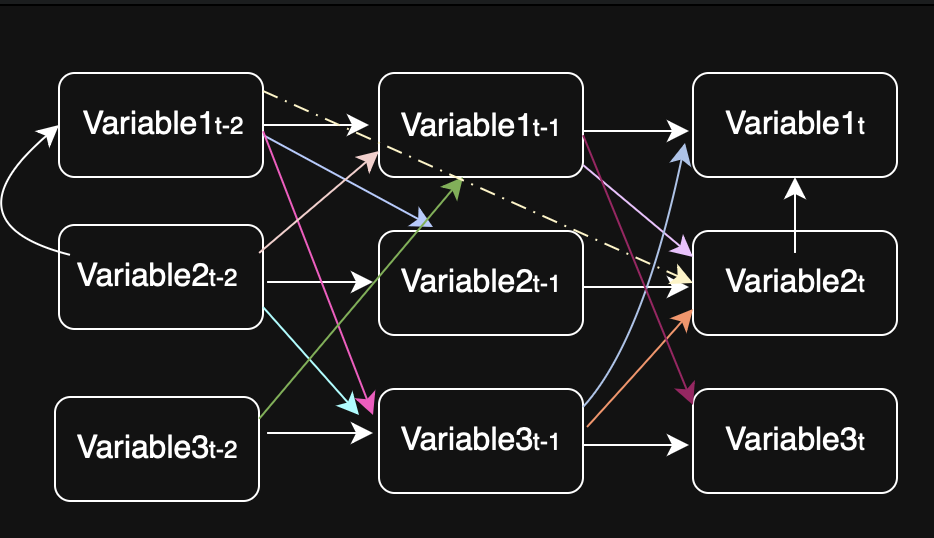



# Get Causality Relationships
We implemented the **PCMCI** based on (Runge et al., 2020).
The pair of variables we used: (log_return_btc, log_return_eth) is assumed to be conditionally independent at some *significance level α0*. 

## Orientation of links

*For lagged links*, time order automatically provides orientation

*For contemporaneous links*, orientation of links are determined by a collider phase and rule phase.

Autoregression helps to identify the orientation of a link.

## Realization of Conditional CI Test
1. *Iteration 1(p = 0)*: Start with unconditional independence tests (p=0) to identify and prune independent variables.By removing pairs like (X8,X9) and (X5,X6) from other variables' adjacency sets, the PC algorithm focuses on local structures.The estimation dimension is reduced compared to  GC framework.

2. *Iteration 2(p = 1)*: CI for all remaining links is tested conditional on all one-dimensional conditioning sets. For example CI will test whether X1(t-1) and X1(t-2) are dependent or independent under the condition X1(t-2)/X0(t-2)/...

## The Removal of True Link

If there is an incorrect CI result eg.X1(t-1)⊥⊥X0(t)|X1(t-2),the true lagged link X1(t-1)→X0(t) will be removed. The false positive X1(t-2)→X0(t) link will be generated.

*Determinant of the detection power of the removal of a true link in a finite sample case*

1. Sample size 
2. Significance level α
3. The CI test dimension (p+2)
4. Effect size
etc

**The Partial Correlation Conditional Test**

Partial Autocorrelation Function(PACF): 

According to Wikipedia, the partial autocorrelation function (PACF) gives the partial correlation of a stationary time series with its own lagged values, regressed the values of the time series at all shorter lags.

𝜙1,1 = corr(z(t+1),z(t)), for k=1

𝜙k,k=corr(z(t+k)-$\widehat{z}$(t+k),z(t)-$\widehat{z}$(t)), for k>=2,

$\widehat{z}$(t+k) and $\widehat{z}$(t) are linear combinations of {z(t+1)...z(t+k-1)} that minimize the mean squared error of z(t+k) and z(t) respectively. 

Under the condition X1(t-2), we want to know whether X1(t-1) and X0(t) is independent or not. We will examine 𝜙 for X1(t-1) and X0(t) by regressing out X1(t-2)：

$\widehat{X1}$(t-1)=X1(t-2)βX1(t-1) 

$\widehat{X0}$(t)=X1(t-2)βX0(t)

𝜙= corr(X1(t-1)-$\widehat{X1}$(t-1),X0(t)-$\widehat{X0}$(t))

If |𝜙|《=α0，X1(t-1)⊥⊥X0(t).

Else, X1(t-1) and X0(t) is correlated.

We denote the ParCorr (Partial Correlation) value as I(Xi(t−τ); Xj(t)|S) where S is the conditioning set.  

For each P-iteration: the sample size, α, the dimension(p+2) remains the same.
If I(Xi(t−τ); Xj(t)|S) falls below α for any considered S: a link will be removed. The effect size minS[I(Xi(t−τ); Xj(t)|S)] is a determinant of whether a link will be removed or not. 


In [ ]:
class CausalPrecursors():
    def __init__(self, name='crypto_data',
                 cond_ind_test='parcorr',#conditional independence test method, currently only support partial correlation test (ParCorr)
                 window=10,#maximum time lag to consider for causal links
                 sig_thres=0.05, #significance level for conditional independence test
                 var_names=['btc_vol','eth_vol'],#names of the features we want to analyze
                 depth=3,#maximum number of parents to consider for each variable
                 num_features=2):
            if cond_ind_test=='parcorr':
                self.cond_ind_test = ParCorr()
            elif cond_ind_test == '':
                raise ValueError('Not support yet!')
            if len(var_names) != num_features:
                raise ValueError('Give coincidence number and name of features!')
            self.name = name
            self.sig_thres = sig_thres
            self.window = window
            self.var_names = var_names
            self.depth = depth
            self.num_features = num_features

    def __call__(self, data):
       '''main function to get causal precursors for the target variable'''
       print('1. get causaity based on PCMCI for {} features with {} window'.\
            format(self.num_features, self.window))
       self.get_causal_precursors(data)
       print('2. plot line chart of causal strength for {} features with {} window'.\
             format(self.num_features, self.window))
       self.plot_line_chart()
       print('3. group causal drivers for the same causal activation time')
       self.group_causal_prescursors()
       print('4. prune causal links')
       self.prune_causal_link(np.array(data))
       print('5. get group {} trees'.\
            format(len(self.causal_link_groups.keys())))
       self.get_group_trees()
       return self
    def get_causal_precursors(self, data):
         '''1. Format Data to a 3D array of shape 
         2. Run PCMCI to get causal precursors for the target variable.'''
         dataframe = data_processing.DataFrame(np.array(data))
         self.pcmci = PCMCI(
            dataframe=dataframe,
            cond_ind_test=self.cond_ind_test)
         self.pcmci.run_pcmci(
            tau_max=self.window,
            pc_alpha=None)
    def plot_heatmap(self):
                print(f"Drawing causality heatmap for {self.name}...")
                val_matrix = self.pcmci.val_matrix
                combined_matrix = np.mean(np.abs(val_matrix), axis=2)
                fig, ax = plt.subplots(figsize=(10, 8))
                im = ax.imshow(combined_matrix, cmap='YlOrRd') # 使用黄-橙-红渐变
                ax.set_xticks(np.arange(len(self.var_names)))
                ax.set_yticks(np.arange(len(self.var_names)))
                ax.set_xticklabels(self.var_names)
                ax.set_yticklabels(self.var_names)
                plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
                for i in range(len(self.var_names)):
                    for j in range(len(self.var_names)):
                        val = combined_matrix[i, j]
                        if val >= self.sig_thres: # 只标注显著的
                            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black")

                ax.set_title(f"Causal Strength Heatmap (Mean over {self.window} lags)")
                fig.colorbar(im, ax=ax, label='Causal Strength (abs val)')
                fig.tight_layout()
                save_path = f"{self.name}_causality_structure.png"
                plt.savefig(save_path)
                print(f"Plot saved to {save_path}")
                plt.show()
    def plot_line_chart(self):
        btc_to_eth = np.abs(self.pcmci.val_matrix[0, 1, :])
        eth_to_btc = np.abs(self.pcmci.val_matrix[1, 0, :])
        btc_to_btc = np.abs(self.pcmci.val_matrix[0, 0, :])
        eth_to_eth = np.abs(self.pcmci.val_matrix[1, 1, :])
        fig, ax = plt.subplots(figsize=(10, 5))
        lags = np.arange(len(btc_to_eth))
        ax.plot(lags[1:], btc_to_eth[1:], label='BTC -> ETH', marker='o', linewidth=2)
        ax.plot(lags[1:], eth_to_btc[1:], label='ETH -> BTC', marker='s', linewidth=2)
        ax.plot(lags[1:], btc_to_btc[1:], label='BTC -> BTC', marker='^', linewidth=2)
        ax.plot(lags[1:], eth_to_eth[1:], label='ETH -> ETH', marker='d', linewidth=2)
        ax.axhline(y=self.sig_thres, color='r', linestyle='--', label=f'Threshold ({self.sig_thres})')
        ax.set_title('Causal Strength over Time Lags')
        ax.set_xlabel('Lag (Time Steps)')
        ax.set_ylabel('Causal Strength (Absolute Value)')
        ax.set_xticks(lags[1:]) 
        ax.grid(True, alpha=0.3)
        ax.legend() 
        plt.tight_layout()
        plt.show()   


In [3]:
eth = pd.read_csv('/Users/lizzy/TradeData/ethtrade.csv')
btc = pd.read_csv('/Users/lizzy/TradeData/btctrade.csv')
eth['log_return']=np.log(eth['price']).diff()
btc['log_return']=np.log(btc['price']).diff()
filleth=eth['log_return'].bfill()
fillbtc=btc['log_return'].bfill()
print(eth,btc)

                                date          id    price         timestamp  \
0      2025-10-23 03:56:00.597052928  3045095706  3827.05  1761191760597053   
1      2025-10-23 03:56:01.081235968  3045095707  3827.05  1761191761081236   
2      2025-10-23 03:56:01.090625024  3045095708  3827.05  1761191761090625   
3      2025-10-23 03:56:01.245457920  3045095709  3827.04  1761191761245458   
4      2025-10-23 03:56:01.581384960  3045095710  3827.05  1761191761581385   
...                              ...         ...      ...               ...   
93278  2025-10-23 05:00:59.688209152  3045188984  3838.43  1761195659688209   
93279  2025-10-23 05:00:59.688209152  3045188985  3838.43  1761195659688209   
93280  2025-10-23 05:00:59.688209152  3045188986  3838.43  1761195659688209   
93281  2025-10-23 05:00:59.688209152  3045188987  3838.43  1761195659688209   
93282  2025-10-23 05:00:59.857058048  3045188988  3838.43  1761195659857058   

       log_return  
0             NaN  
1        0.

Drawing causality heatmap for crypto_data...
Plot saved to crypto_data_causality_structure.png


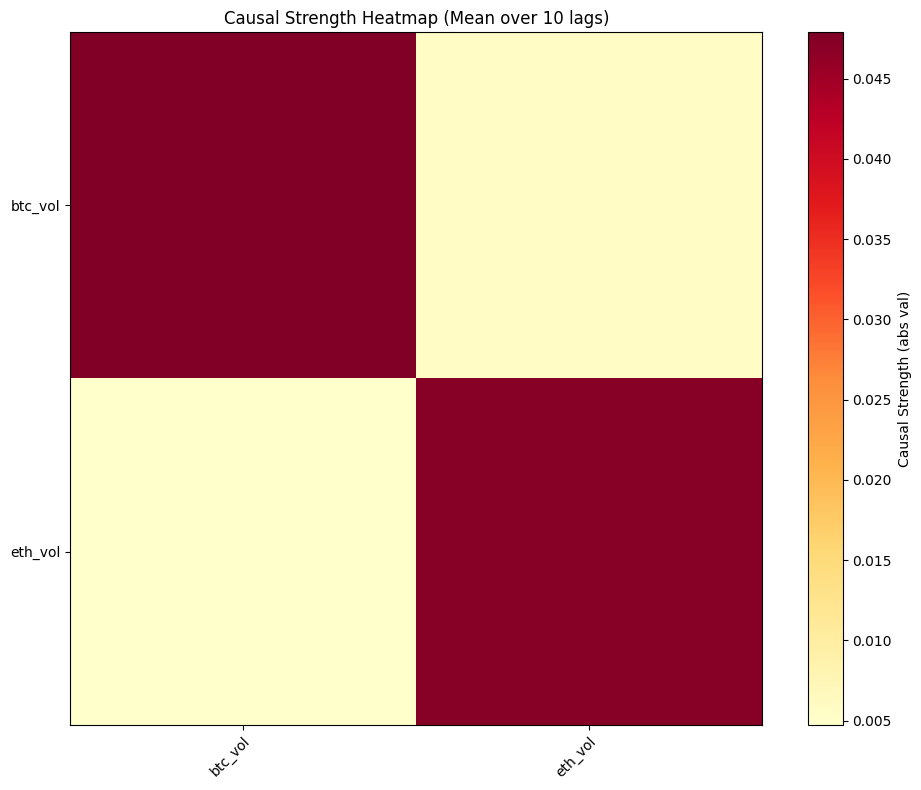

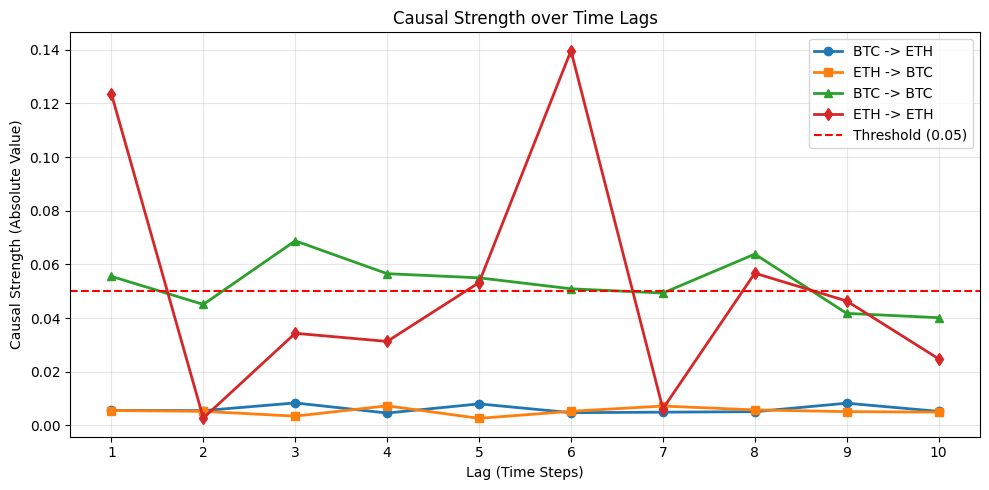

{'1': [0], '3': [0], '4': [0], '5': [0], '6': [0], '8': [0]}
In 10 windows,there are 6 groups of causal precursors for the target variable.


In [98]:

causal_precursors = CausalPrecursors()
data = pd.concat([btc['log_return'], eth['log_return']], axis=1).dropna()
causal_precursors.get_causal_precursors(data)   
causal_precursors.plot_heatmap()
causal_precursors.plot_line_chart()
causal_precursors.group_causal_prescursors()
